# Machine Learning

This notebook explores unsupervised and supervised machine learning methods for analyzing and predicting music emotion.

---
## Unsupervised Learning – PCA

Principal Component Analysis (PCA) is used to reduce the dimensionality of the audio features and investigate whether natural patterns or separation between emotion classes can be identified without using the target labels.

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/processed/moodify_clean.csv")

X = df.drop(columns=["labels"])
y = df["labels"]

### Feature Scaling for PCA

Standardize all audio features before PCA so that variables with larger numerical ranges do not dominate the analysis.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Dimensionality Reduction with PCA

Reduce the ten original audio features to two principal components to visualize the main structure in the data.

In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: [0.34585618 0.12770797]
Total explained variance: 0.47356414950705306


- PC1 captures approximately **34.6%** of the variance.
- PC2 captures approximately **12.8%** of the variance.
- Together, they capture approximately **47.4%** of the total variance.

### PCA Visualization

Visualize the first two principal components and color the observations by their known emotion labels. The labels were not used when PCA created the components; they are added afterward only for interpretation.

In [8]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["labels"] = y.values

label_names = {
    0: "Sad",
    1: "Happy",
    2: "Energetic",
    3: "Calm"
}

pca_df["emotion"] = pca_df["labels"].map(label_names)

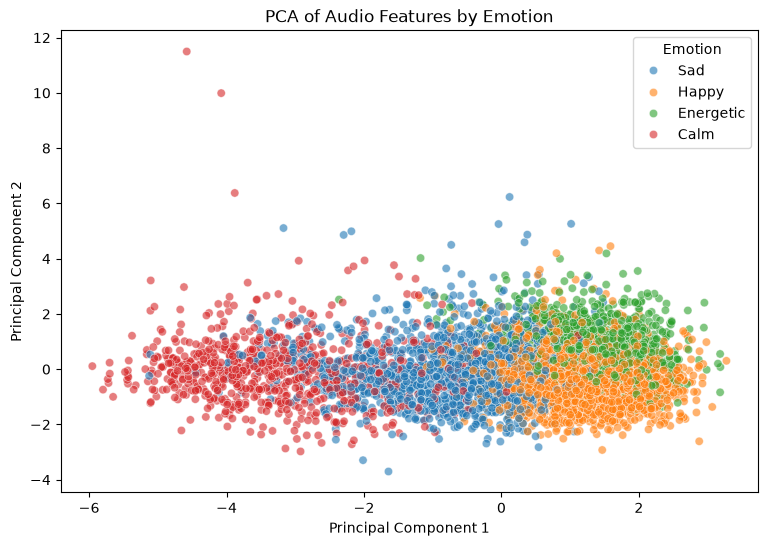

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

pca_sample = pca_df.sample(n=5000, random_state=42)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_sample,
    x="PC1",
    y="PC2",
    hue="emotion",
    hue_order=["Sad", "Happy", "Energetic", "Calm"],
    alpha=0.6
)

plt.title("PCA of Audio Features by Emotion")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Emotion")
plt.show()

**Observation:** PCA reveals meaningful structure between the emotion classes, particularly along PC1.  
Calm tracks are concentrated toward lower PC1 values, while Happy and Energetic tracks tend to appear at higher values. Sad overlaps considerably with several classes, and Happy and Energetic also show substantial overlap. The first two components explain approximately 47.4% of the total variance, so the visualization does not represent all information contained in the original features.

### PCA Feature Loadings

Examine how strongly each original audio feature contributes to the first two principal components.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

loadings

,PC1,PC2
duration (ms),-0.012387,0.506626
danceability,0.310950,-0.496822
energy,0.466703,0.236346
loudness,0.473841,0.094506
speechiness,0.129124,-0.075470
acousticness,-0.424772,-0.231326
instrumentalness,-0.333604,0.105087
liveness,0.116980,0.369406
valence,0.326291,-0.410103
tempo,0.179649,0.238351


In [11]:
loadings.reindex(
    loadings["PC1"].abs().sort_values(ascending=False).index
)

,PC1,PC2
loudness,0.473841,0.094506
energy,0.466703,0.236346
acousticness,-0.424772,-0.231326
instrumentalness,-0.333604,0.105087
valence,0.326291,-0.410103
danceability,0.310950,-0.496822
tempo,0.179649,0.238351
speechiness,0.129124,-0.075470
liveness,0.116980,0.369406
duration (ms),-0.012387,0.506626


**Interpretation:** PC1 is mainly influenced by loudness, energy, acousticness, instrumentalness, valence and danceability. Higher PC1 values are associated with louder, more energetic and danceable tracks, while lower values are associated with more acoustic and instrumental tracks. This helps explain why Calm appears toward lower PC1 values while Happy and Energetic appear toward higher values.

PC2 is influenced mainly by duration, danceability, valence and liveness, but its interpretation is less distinct.

---

## Unsupervised Learning – K-Means Clustering

K-Means clustering is used to investigate whether the audio features naturally form groups without using the known emotion labels. Four clusters are initially created to allow comparison with the four existing emotion classes.

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

pca_df["cluster"] = clusters

In [13]:
pca_df["cluster"].value_counts().sort_index()

cluster
0     66378
1     83797
2     19981
3    106104
Name: count, dtype: int64

### K-Means Clusters in PCA Space

Visualize the clusters discovered by K-Means using the first two principal components.

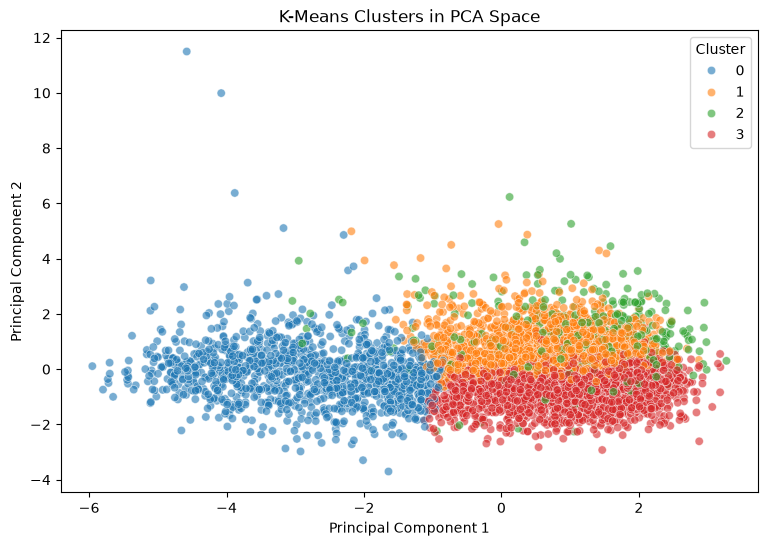

In [14]:
cluster_sample = pca_df.sample(n=5000, random_state=42)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_sample,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### Cluster Composition by Emotion

Compare the discovered K-Means clusters with the known emotion labels. The emotion labels were not used to create the clusters and are only used afterward for interpretation.

In [15]:
cluster_emotion = pd.crosstab(
    pca_df["cluster"],
    pca_df["emotion"],
    normalize="index"
) * 100

cluster_emotion.round(1)

emotion,Calm,Energetic,Happy,Sad
cluster,,,,
0,58.2,0.1,0.1,41.6
1,1.9,38.2,29.3,30.5
2,3.8,26.3,44.7,25.2
3,1.1,8.8,68.0,22.0


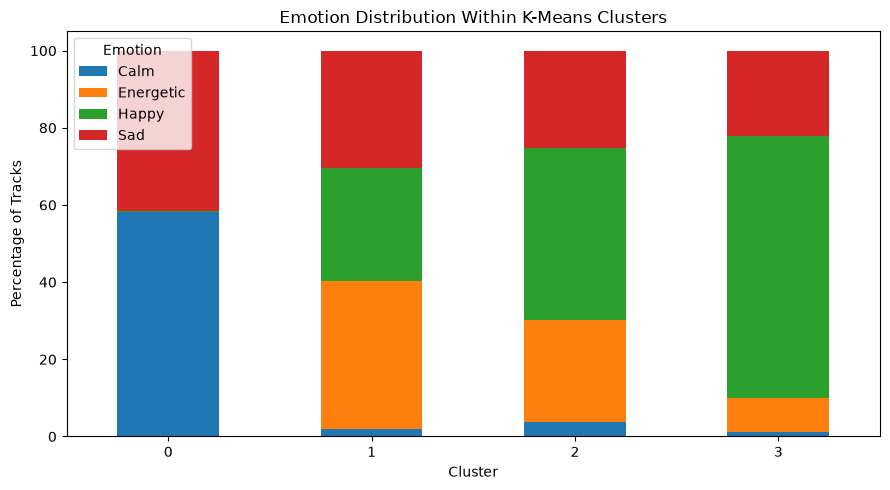

In [16]:
cluster_emotion.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Emotion Distribution Within K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Percentage of Tracks")
plt.legend(title="Emotion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** K-Means identified meaningful structure in the audio features, although the clusters do not correspond directly to the four emotion labels. Cluster 0 is strongly associated with Calm and Sad tracks, while Cluster 3 is dominated by Happy tracks. The remaining clusters contain larger mixtures of emotions.

This suggests that the audio features contain natural groupings related to emotion, but the predefined emotion classes cannot be completely separated through unsupervised clustering alone.

---
---

## Supervised Learning

The goal of the supervised learning stage is to predict one of four emotion classes — Sad, Happy, Energetic or Calm — using the audio features.

---

### Train-Test Split

Split the data into 80% training data and 20% test data. Stratification preserves the original class distribution in both sets.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["labels"])
y = df["labels"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (221008, 10)
Test set: (55252, 10)


### Baseline Model – Dummy Classifier

A Dummy Classifier is used as a simple baseline. It predicts the most frequent emotion class without learning patterns from the audio features. More advanced models should clearly outperform this baseline.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_predictions)

print(f"Baseline accuracy: {dummy_accuracy:.4f}")

Baseline accuracy: 0.3827


**Result:** The baseline model achieved an accuracy of 38.27%. Since it always predicts the most frequent class (Happy), a useful machine learning model should perform substantially better than this baseline.

### Logistic Regression

Logistic Regression is used as the first supervised classification model. The features are standardized using only the training data to prevent data leakage.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

### Logistic Regression Evaluation

Evaluate the model using accuracy and a classification report to examine performance for each emotion class.

In [20]:
from sklearn.metrics import accuracy_score, classification_report

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Accuracy: {logistic_accuracy:.4f}")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Sad", "Happy", "Energetic", "Calm"]
    )
)

Accuracy: 0.8370
              precision    recall  f1-score   support

         Sad       0.85      0.82      0.83     16326
       Happy       0.81      0.84      0.83     21145
   Energetic       0.80      0.77      0.78      9343
        Calm       0.93      0.94      0.93      8438

    accuracy                           0.84     55252
   macro avg       0.85      0.84      0.84     55252
weighted avg       0.84      0.84      0.84     55252



**Calm: F1 = 0.93**  
**Sad: F1 = 0.83**  
**Happy: F1 = 0.83**  
**Energetic: F1 = 0.78**

**Result:** Logistic Regression achieved 83.70% accuracy, substantially outperforming the 38.27% baseline. Calm was classified most successfully (F1 = 0.93), while Energetic had the lowest performance (F1 = 0.78). Contrary to the initial hypothesis, Sad was not the most difficult class to predict.

### Confusion Matrix

Visualize the model's predictions to identify which emotion classes are most frequently confused with each other.

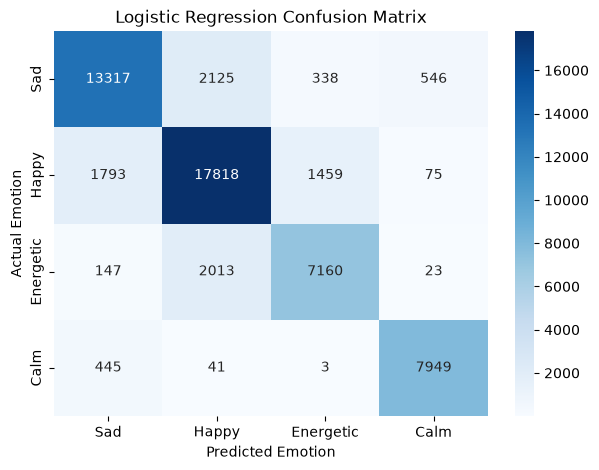

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sad", "Happy", "Energetic", "Calm"],
    yticklabels=["Sad", "Happy", "Energetic", "Calm"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

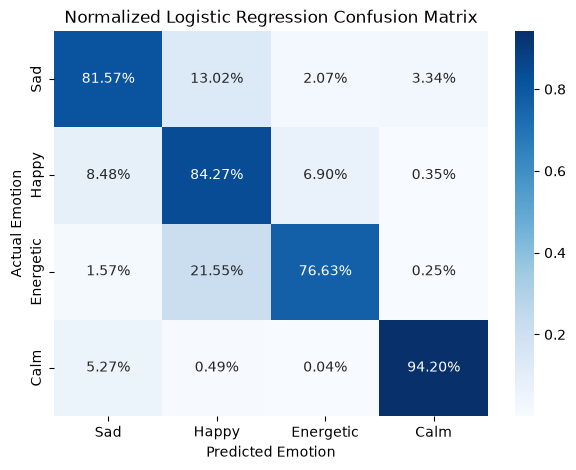

In [22]:
cm_normalized = confusion_matrix(
    y_test,
    logistic_predictions,
    normalize="true"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["Sad", "Happy", "Energetic", "Calm"],
    yticklabels=["Sad", "Happy", "Energetic", "Calm"]
)

plt.title("Normalized Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

**Calm:** 94.20% correctly classified → a very distinct class.  
**Happy:** 84.27% correctly classified.  
**Sad:** 81.57% correctly classified. When misclassified, Sad is most often predicted as Happy (13.02%).  
**Energetic:** only 76.63% correctly classified. As many as 21.55% of Energetic tracks are misclassified as Happy.

**Interpretation:** The confusion matrices show that Calm is the easiest emotion to classify, with 94.20% correctly predicted. Energetic is the most difficult, with 76.63% correctly classified and 21.55% incorrectly predicted as Happy. This supports the earlier EDA, where substantial overlap between Happy and Energetic was observed. Sad is also sometimes confused with Happy, but performs better than initially expected.

---

### Random Forest

Random Forest is used as a more flexible classification model that can capture non-linear relationships and interactions between the audio features.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

### Random Forest Evaluation

Evaluate Random Forest using accuracy and class-specific precision, recall and F1-score, and compare its performance with Logistic Regression.

In [24]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Sad", "Happy", "Energetic", "Calm"]
    )
)

Random Forest Accuracy: 0.9399
              precision    recall  f1-score   support

         Sad       0.95      0.94      0.95     16326
       Happy       0.93      0.95      0.94     21145
   Energetic       0.92      0.89      0.91      9343
        Calm       0.97      0.98      0.97      8438

    accuracy                           0.94     55252
   macro avg       0.94      0.94      0.94     55252
weighted avg       0.94      0.94      0.94     55252



**Dummy baseline:** 38.27%  
**Logistic Regression:** 83.70%  
**Random Forest:** 93.99%

**Result:** Random Forest achieved 93.99% accuracy, substantially outperforming Logistic Regression (83.70%) and the baseline (38.27%). Performance improved across all emotion classes. Energetic remained the most difficult class, but its F1-score increased from 0.78 with Logistic Regression to 0.91 with Random Forest.

### Normalized Confusion Matrix

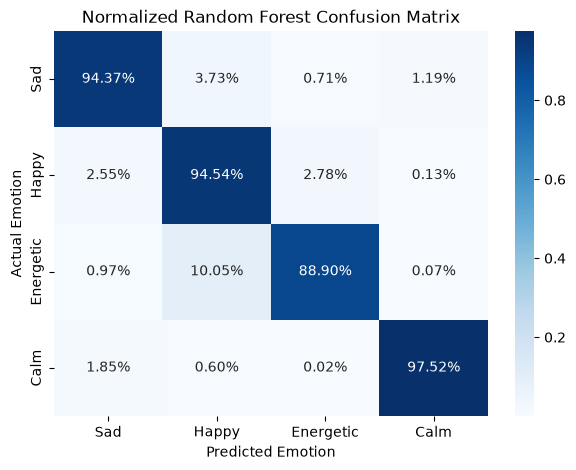

In [25]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    normalize="true"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["Sad", "Happy", "Energetic", "Calm"],
    yticklabels=["Sad", "Happy", "Energetic", "Calm"]
)

plt.title("Normalized Random Forest Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

### Feature Importance

Examine which audio features contributed most to the Random Forest predictions.

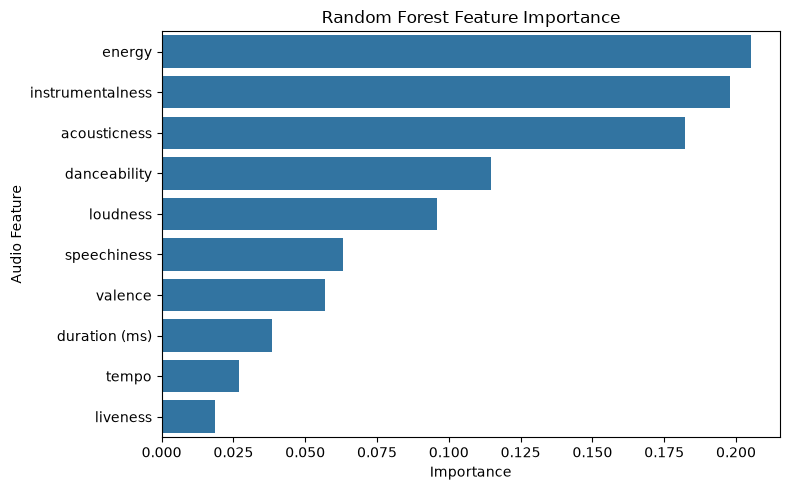

energy              0.205061
instrumentalness    0.197816
acousticness        0.182211
danceability        0.114830
loudness            0.095853
speechiness         0.063286
valence             0.056982
duration (ms)       0.038417
tempo               0.026994
liveness            0.018549
dtype: float64

In [26]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()

feature_importance

**Interpretation:** Random Forest improved classification across all emotion classes. Calm achieved the highest recall (97.52%), while Energetic remained the most difficult class (88.90%). Energetic was primarily confused with Happy (10.05%), consistent with the overlap observed during EDA.

Feature importance shows that energy contributes most strongly to the Random Forest predictions, followed by instrumentalness and acousticness. This only partially supports the initial hypothesis, as valence and tempo were less important than expected.

---

### XGBoost

XGBoost is used as a gradient boosting model to compare its performance with Random Forest. Unlike Random Forest, XGBoost builds trees sequentially, where each new tree attempts to correct errors made by previous trees.

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

In [28]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=["Sad", "Happy", "Energetic", "Calm"]
    )
)

XGBoost Accuracy: 0.9640
              precision    recall  f1-score   support

         Sad       0.97      0.97      0.97     16326
       Happy       0.96      0.96      0.96     21145
   Energetic       0.95      0.94      0.94      9343
        Calm       0.98      0.99      0.98      8438

    accuracy                           0.96     55252
   macro avg       0.97      0.96      0.96     55252
weighted avg       0.96      0.96      0.96     55252



**Result:** XGBoost achieved the best supervised machine learning performance with 96.40% accuracy, improving upon Random Forest (93.99%) and Logistic Regression (83.70%). Performance was strong across all four emotion classes. Energetic remained the most difficult class, but its F1-score improved to 0.94.

### XGBoost Confusion Matrix

Examine which emotion classes are still confused by the best-performing supervised machine learning model.

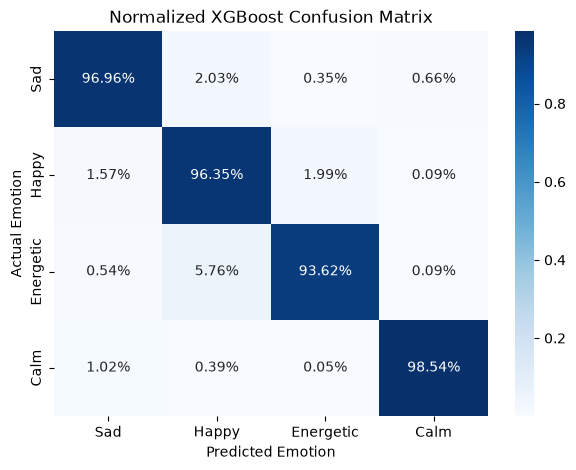

In [29]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_predictions,
    normalize="true"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["Sad", "Happy", "Energetic", "Calm"],
    yticklabels=["Sad", "Happy", "Energetic", "Calm"]
)

plt.title("Normalized XGBoost Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.show()

**Interpretation:** XGBoost achieved strong performance across all four emotion classes. Calm remained the easiest class to identify, with 98.54% correctly classified, while Energetic remained the most difficult at 93.62%.

The largest remaining confusion occurs between Energetic and Happy, with 5.76% of Energetic tracks classified as Happy. However, this confusion decreased substantially compared with Random Forest (10.05%) and Logistic Regression (21.55%), showing that XGBoost handles the overlap between these classes more effectively.

---

## Machine Learning Summary

The supervised models showed a clear improvement as more flexible non-linear methods were introduced:

- Dummy Classifier: 38.27%
- Logistic Regression: 83.70%
- Random Forest: 93.99%
- XGBoost: 96.40%

PCA and K-Means showed that the audio features contain meaningful structure related to emotion, although the emotion classes could not be clearly separated using unsupervised learning alone.

Among the supervised models, XGBoost achieved the best performance. Energetic consistently remained the most difficult emotion to classify, particularly due to confusion with Happy, while Calm was the most distinct class.

Overall, the results show that non-linear ensemble models are highly effective for classifying emotion from the selected audio features.